<a href="https://colab.research.google.com/github/pratheekshashetty-blip/machinelearningprojects/blob/main/mall_spending.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mall Customer Segmentation using Machine Learning

Objective:
Segment mall customers based on income and spending behaviour
using clustering algorithms such as K-Means and DBSCAN.

Dataset: https://www.kaggle.com/datasets/shwetabh123/mall-customers

In [ ]:
%matplotlib inline

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

In [ ]:
# Load data

df = pd.read_csv('Mall_Customers.csv')
df.columns = ['CustomerID', 'Genre', 'Age', 'Income', 'Spending']

print(df.shape)
print(df.describe())
print(df.isnull().sum())

(200, 5)
       CustomerID         Age      Income    Spending
count  200.000000  200.000000  200.000000  200.000000
mean   100.500000   38.850000   60.560000   50.200000
std     57.879185   13.969007   26.264721   25.823522
min      1.000000   18.000000   15.000000    1.000000
25%     50.750000   28.750000   41.500000   34.750000
50%    100.500000   36.000000   61.500000   50.000000
75%    150.250000   49.000000   78.000000   73.000000
max    200.000000   70.000000  137.000000   99.000000
CustomerID    0
Genre         0
Age           0
Income        0
Spending      0
dtype: int64


In [ ]:
#  Scale features
X = df[['Income', 'Spending']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


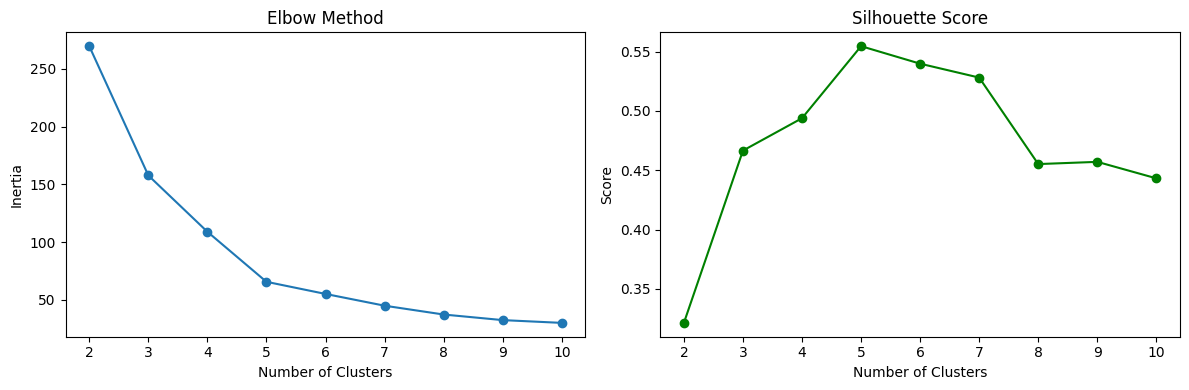

In [ ]:
#Find optimal k — Elbow + Silhouette
inertias, sil_scores = [], []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K), inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(K), sil_scores, marker='o', color='green')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters')
axes[1].set_ylabel('Score')
plt.tight_layout()
plt.show()


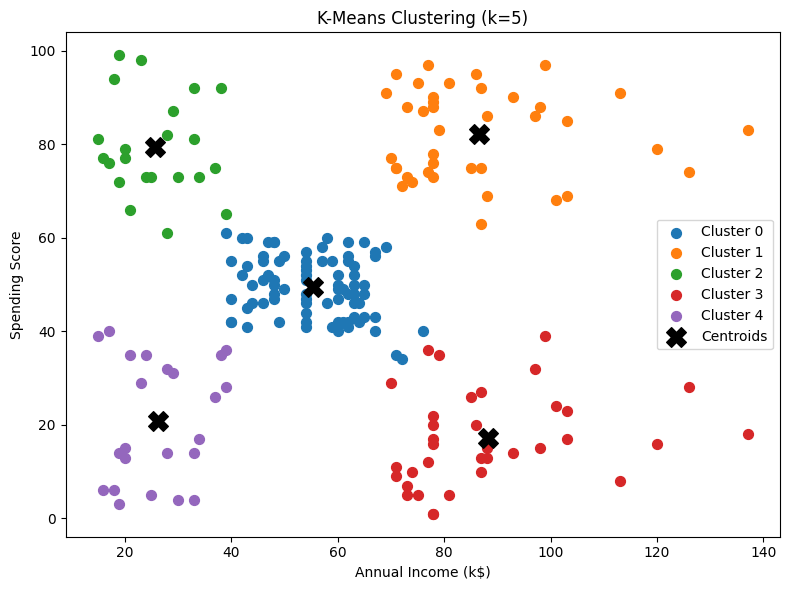

In [ ]:
# K-Means (k=5)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
for cluster in sorted(df['kmeans_cluster'].unique()):
    subset = df[df['kmeans_cluster'] == cluster]
    plt.scatter(subset['Income'], subset['Spending'], label=f'Cluster {cluster}', s=50)

centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], c='black', marker='X', s=200, label='Centroids')
plt.title('K-Means Clustering (k=5)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.legend()
plt.tight_layout()
plt.show()
plt.close()



In [ ]:
#  Cluster analysis
summary = df.groupby('kmeans_cluster')[['Income', 'Spending', 'Age']].mean().round(1)
summary['count'] = df.groupby('kmeans_cluster').size()
print('\nCluster Summary:')
print(summary)



Cluster Summary:
                Income  Spending   Age  count
kmeans_cluster                               
0                 55.3      49.5  42.7     81
1                 86.5      82.1  32.7     39
2                 25.7      79.4  25.3     22
3                 88.2      17.1  41.1     35
4                 26.3      20.9  45.2     23


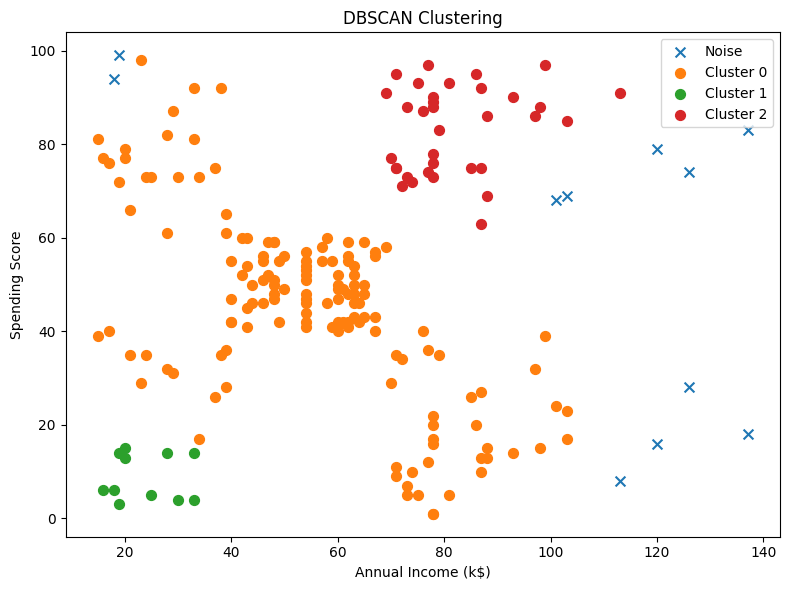


DBSCAN — clusters: 3, noise points: 11


In [ ]:
# DBSCAN

dbscan = DBSCAN(eps=0.45, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
for cluster in sorted(df['dbscan_cluster'].unique()):
    subset = df[df['dbscan_cluster'] == cluster]
    label = 'Noise' if cluster == -1 else f'Cluster {cluster}'
    marker = 'x' if cluster == -1 else 'o'
    plt.scatter(subset['Income'], subset['Spending'], label=label, marker=marker, s=50)

plt.title('DBSCAN Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.legend()
plt.tight_layout()
plt.show()
plt.close()


print(f"\nDBSCAN — clusters: {df['dbscan_cluster'].nunique() - 1}, noise points: {(df['dbscan_cluster'] == -1).sum()}")

Model Evaluation

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, kmeans.labels_)
print("Silhouette Score:", score)

Silhouette Score: 0.4426214845978157


In [ ]:

score = silhouette_score(X, dbscan.labels_)
print("DBSCAN Silhouette Score:", score)

DBSCAN Silhouette Score: 0.3200802658739474


This project applied unsupervised ML techniqes to segment Mall coustomer spendings based on their annual income and spending behaviour.




The analysis identified five distinct customer groups with different purchasing behaviors. These clusters can help businesses better understand their customers and design targeted marketing strategies.

Both DBSCAN and Kmeans were used, but KMeans provided clearer and more meaningful customer segments for this dataset.